In [85]:
import pandas as pd

In [86]:
# seed3つの平均スコアを計算する関数
def get_avg_score(df):
    df["model"] = df["name"].str.replace(r"_seed\d+", "", regex=True)
    df_avg=df.groupby("model").mean(numeric_only=True).reset_index()
    return df_avg

In [87]:
# mlpのparamsを計算する関数
def mlp_params(input_dim,output_dim):
    # hidden size 1024, layers 2
    hidden_size = 1024
    layer1 = (input_dim * hidden_size) + hidden_size
    layer2 = (hidden_size * hidden_size) + hidden_size
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

In [88]:
# rnnのparamsを計算する関数
def rnn_params(input_dim,output_dim):
    # hidden size 400, layers 2, LSTM Cell
    hidden_size = 400
    layer1 = 4 * ((input_dim + hidden_size) * hidden_size + hidden_size)
    layer2 = 4 * ((hidden_size + hidden_size) * hidden_size + hidden_size)
    layer3 = (hidden_size * output_dim) + output_dim
    params = layer1 + layer2 + layer3
    return params

In [89]:
# ncpのparamsを計算する関数
def ncp_params(input_dim, output_dim, units):
    layer1 = (input_dim * units) + units
    params_1 = units * 3 #gleak,vleak,cm
    params_2 = units * units * 5 # sigma, mu, w, erev, sparsity_mask
    params_3 = input_dim * units * 5 # sensory_sigma, sensory_mu, sensory_w, sensory_erev, sensory_sparsity_mask
    layer2 = (units * output_dim) + output_dim
    params = layer1 + params_1 + params_2 + params_3 + layer2
    return params

In [90]:
import re
def calculate_model_size(df, task):
    df = df.copy()
    if task == "lift": #[10,3,4,2]
        input_dim = 19
        output_dim = 7
    elif task == "can": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    elif task == "square": #[14,3,4,2]
        input_dim = 23
        output_dim = 7
    else:
        raise ValueError("Unknown task")
    for model in df["model"].unique():
        idx = df["model"] == model
        if model == "bc-pure":
            df.loc[idx, "params"] = mlp_params(input_dim,output_dim)
        elif model == "bc-rnn-pure":
            df.loc[idx, "params"] = rnn_params(input_dim,output_dim)
        elif model.startswith("ncp"):
            u = int(re.search(r"_u(\d+)", model).group(1))
            df.loc[idx, "params"] = ncp_params(input_dim,output_dim,u)
        else:
            raise ValueError("Unknown model")
    return df

In [93]:
df_lift=pd.read_csv('/work/robomimic/csv/eval/lift/lift-best.csv')
df_can=pd.read_csv('/work/robomimic/csv/can/can-best.csv')
df_square=pd.read_csv('/work/robomimic/csv/square/square-best.csv')
df_can_avg=get_avg_score(df_can)
df_can_avg=calculate_model_size(df_can_avg, "can")
df_lift_avg=get_avg_score(df_lift)
df_lift_avg=calculate_model_size(df_lift_avg, "lift")
df_square_avg=get_avg_score(df_square)
df_square_avg=calculate_model_size(df_square_avg, "square")

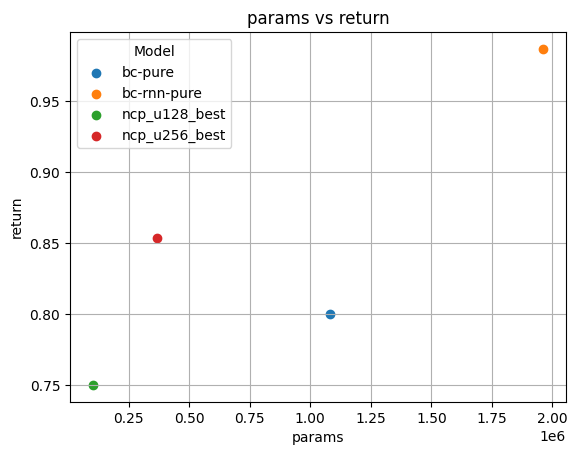

In [92]:
import matplotlib.pyplot as plt

plt.figure()

for model in df_can_avg["model"].unique():
    df_m = df_can_avg[df_can_avg["model"] == model]
    plt.scatter(df_m["params"], df_m["return"], label=model)

plt.xlabel("params")
plt.ylabel("return")
plt.title("params vs return")
plt.legend(title="Model")
plt.grid(True)
plt.show()

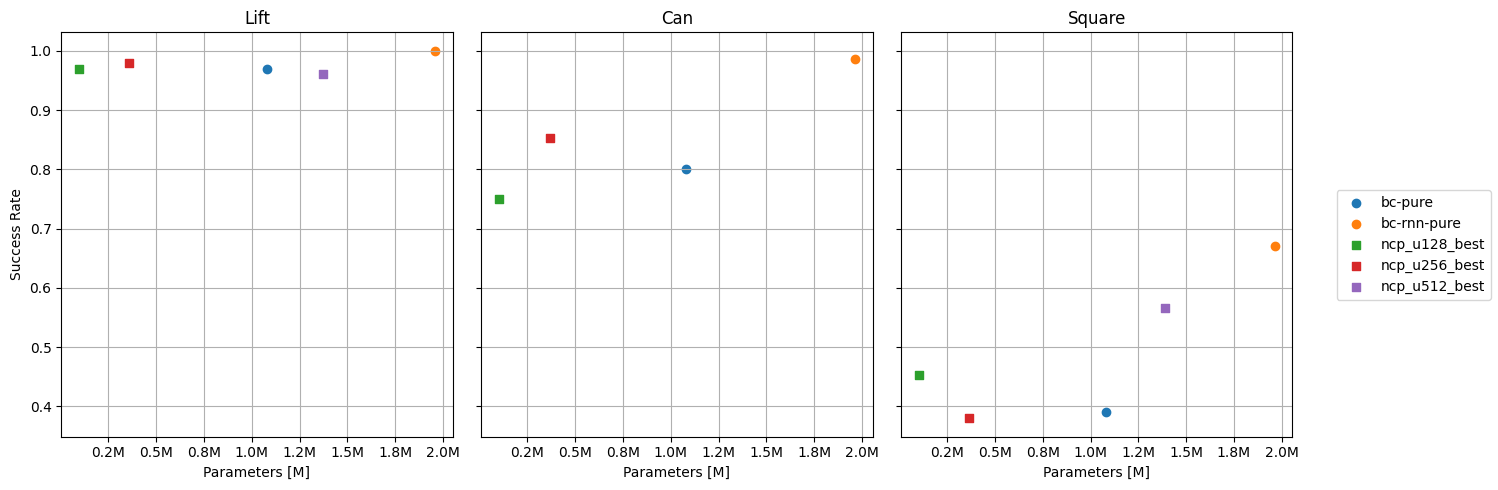

In [95]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = {
    "Lift": df_lift_avg,
    "Can": df_can_avg,
    "Square": df_square_avg
}

# モデルごとの色とマーカー設定
model_styles = {}
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def get_style(model):
    if model not in model_styles:
        color = colors[len(model_styles) % len(colors)]
        marker = "s" if "ncp" in model.lower() else "o"  # ncpは四角
        model_styles[model] = {"color": color, "marker": marker}
    return model_styles[model]

for ax, (title, df) in zip(axes, datasets.items()):
    for model in df["model"].unique():
        sub = df[df["model"] == model]
        style = get_style(model)

        ax.scatter(
            sub["params"],
            sub["success_rate"],
            label=model,
            color=style["color"],
            marker=style["marker"]
        )

    ax.set_title(title)
    ax.set_xlabel("Parameters [M]")
    ax.grid(True)

# y軸は success rate
axes[0].set_ylabel("Success Rate")

# x軸を M 表記に変換
for ax in axes:
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M")
    )

# 凡例は右側にまとめて配置
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", frameon=True)

plt.tight_layout(rect=[0, 0, 0.88, 1])  # 凡例スペース確保
plt.show()
